# 1. Libraries

In [2]:
import pandas as pd
import numpy as np
import re
import os
import ast
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.metrics.pairwise import cosine_similarity
import random
from scipy.stats import variation
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Helpers

In [3]:
def extract_domain(url):
    pattern = r'\.(.*)'
    domain = re.search(pattern, url)
    if domain:
        return domain.group(0)
    else:
        return None
    
def cosine_similarity_adapter(x, y):
    """ 
    Calcs the cosine similarity between two vectors
    """
    return cosine_similarity(x.reshape(1, -1), y.reshape(1, -1))[0][0]

def dist_and_cv_dv(model):
    """
    Calculates the average sim and coeff of var for 10,000 random pairs of docs
        Inputs: 
            - model (word2vec model): a model trained on a president corpus

        Outputs:
            - mean_dist (float): the mean cosine similarity of the 10,000 pairs
            - cv (float): the coefficient of variation of the 10,000 pairs
    """
    distances = []
    doc_indexes = len(model.dv.key_to_index.keys()) - 1
    for i in range(10000): 
        rand1 = model.dv.index_to_key[random.randrange(0, doc_indexes)]
        rand2 = model.dv.index_to_key[random.randrange(0, doc_indexes)]
        dist = model.dv.similarity(rand1, rand2) + 1
        distances.append(dist)
        
    mean_dist = float(sum(distances)) / float(len(distances))
    cv        = variation(distances)

    return mean_dist, cv

# 3. Data wrangling

In [4]:
file_path = r"C:\Users\asarr\Documents\Projects\pol-cul-maps-latam\president_csvs\5k"

docs = None

for i, file_name in enumerate(os.listdir(file_path)):
    file_full_path = os.path.join(file_path, file_name)
    df = pd.read_csv(file_full_path)
    
    if docs is None:
        docs = df
    else:
        docs = pd.concat([docs, df], ignore_index=True)

df.head()

,Unnamed: 0,textid,words_number,genre,country,website,url,title,text,id_string,text2,tokenized_text,normalized_text
0,443781,717438,652.0,b,HN,aficionfolklorica.blogspot.com,http://aficionfolklorica.blogspot.com/2009/07/...,Cultura Popular: ¿Y si Zelaya vuelve?,Los Forjadores El historiador hondureño Mario...,717438,los forjadores el historiador hondureño mario...,"['los', 'forjadores', 'el', 'historiador', 'ho...","['forjador', 'historiador', 'hondureño', 'mari..."
1,443788,717450,598.0,b,HN,aficionfolklorica.blogspot.com,http://aficionfolklorica.blogspot.com/2009/09/...,Cultura Popular: Decreto estupido,Los Forjadores El historiador hondureño Mario...,717450,los forjadores el historiador hondureño mario...,"['los', 'forjadores', 'el', 'historiador', 'ho...","['forjador', 'historiador', 'hondureño', 'mari..."
2,443829,717542,672.0,b,HN,aficionfolklorica.blogspot.com,http://aficionfolklorica.blogspot.com/2011_02_...,Cultura Popular: febrero 2011,Los Forjadores El historiador hondureño Mario...,717542,los forjadores el historiador hondureño mario...,"['los', 'forjadores', 'el', 'historiador', 'ho...","['forjador', 'historiador', 'hondureño', 'mari..."
3,443880,717628,551.0,b,HN,arquetipounah.blogspot.com,http://arquetipounah.blogspot.com/2010/03/pint...,ARQUETIPO: Pinta Tu Facu,17.3.10 Pinta Tu Facu PINTA TU FACU MAS DE ...,717628,17310 pinta tu facu pinta tu facu mas de lo...,"['17310', 'pinta', 'tu', 'facu', 'pinta', 'tu'...","['pinta', 'facu', 'pinta', 'facu', 'esperar', ..."
4,443955,717740,508.0,b,HN,audienciasinesperadas.blogspot.com,http://audienciasinesperadas.blogspot.com/2009...,el miedo a que el chancho desfile - audiencias...,jueves 27 de agosto de 2009 EL MIEDO A QUE EL...,717740,jueves 27 de agosto de 2009 el miedo a que el...,"['jueves', '27', 'de', 'agosto', 'de', '2009',...","['jueves', 'agosto', 'miedo', 'chancho', 'desf..."


In [4]:
docs['domain'] = docs['website'].apply(extract_domain)

In [ ]:
orgs_df = pd.DataFrame(columns=docs.columns)
govs_df = pd.DataFrame(columns=docs.columns)
blogs_df = pd.DataFrame(columns=docs.columns)
news_df = pd.DataFrame(columns=docs.columns)

# Create lists to store rows temporarily
orgs_list, govs_list, blogs_list, news_list = [], [], [], []

# Iterate through rows
for index, row in docs.iterrows():
    if pd.isna(row['domain']):
        continue
    if 'org' in row['domain']:
        orgs_list.append(row)
    elif 'gov' in row['domain']:
        govs_list.append(row)
    else:
        if row['genre'] == 'b':
            blogs_list.append(row)
        else:
            news_list.append(row)

# Convert lists to DataFrames
orgs_df = pd.concat([orgs_df, pd.DataFrame(orgs_list)], ignore_index=True)
govs_df = pd.concat([govs_df, pd.DataFrame(govs_list)], ignore_index=True)
blogs_df = pd.concat([blogs_df, pd.DataFrame(blogs_list)], ignore_index=True)
news_df = pd.concat([news_df, pd.DataFrame(news_list)], ignore_index=True)

In [7]:
names = ['orgs', 'govs', 'blogs', 'news']

# 4. Average cosine similarity in sources

In [20]:
tagged_data = []

for i, pres_df in enumerate([orgs_df, govs_df, blogs_df, news_df]):
    name = names[i]
    # pres_df['normalized_text'] = pres_df['normalized_text'].apply(lambda x: ast.literal_eval(x)) #TODO: quitar si no es necesario
    pres_df = pres_df.sample(500)
    #create list of lists of tagged word
    tagged_data += [TaggedDocument(words=doc, tags=[name + '_' + str(j)]) for j, doc in enumerate(pres_df['normalized_text'])]

#train model
model = Doc2Vec(vector_size=100, window=6, min_count=2, epochs = 40)
model.build_vocab(tagged_data)
model.train(tagged_data, total_examples=model.corpus_count, epochs=model.epochs)

In [21]:
cs_dict = {'Source': []}

for i, vector in enumerate(model.dv.vectors):
    source = model.dv.index_to_key[i].split('_')[0]
    cs_dict['Source'].append(source)
    row = [cosine_similarity_adapter(vector, vector2) for vector2 in model.dv.vectors]
    cs_dict[model.dv.index_to_key[i]] = row

In [23]:
df = pd.DataFrame(cs_dict)
df.head()

,Source,orgs_0,orgs_1,orgs_2,orgs_3,orgs_4,orgs_5,orgs_6,orgs_7,orgs_8,...,news_490,news_491,news_492,news_493,news_494,news_495,news_496,news_497,news_498,news_499
0,orgs,1.000000,0.316701,0.148508,-0.111132,0.107407,0.123563,0.024802,0.236662,-0.002575,...,0.325179,0.177822,0.085940,0.264720,-0.210634,0.178470,0.235198,0.297282,0.125358,-0.007124
1,orgs,0.316701,1.000000,0.066878,0.126513,0.074950,-0.030525,0.266098,-0.224596,0.114916,...,0.195728,-0.088277,-0.014140,0.575668,0.253516,-0.134570,0.162801,0.179482,0.213820,0.143429
2,orgs,0.148508,0.066878,1.000000,-0.213815,0.104353,-0.094505,-0.202187,-0.065187,-0.002986,...,0.226613,-0.216417,0.017602,-0.109634,0.061878,-0.150665,0.302013,0.304903,0.137413,0.043964
3,orgs,-0.111132,0.126513,-0.213815,1.000000,0.408008,0.071473,0.199677,0.214322,0.202416,...,0.164865,0.099982,0.113932,0.122484,0.063982,0.178254,-0.322483,0.089672,-0.137562,0.011095
4,orgs,0.107407,0.074950,0.104353,0.408008,1.000000,0.102265,0.022359,0.349316,0.299968,...,0.318742,0.460909,0.144953,0.133776,-0.020918,-0.034333,0.150699,0.284614,0.026975,0.238230


In [24]:
for column in df.columns:
    if column != 'Source':
        df[column] = pd.to_numeric(df[column], errors='coerce')

In [33]:
sources = df['Source'].unique()

avg_similarity = pd.DataFrame(np.zeros((len(sources), len(sources))), index=sources, columns=sources)
var_similarity = pd.DataFrame(np.zeros((len(sources), len(sources))), index=sources, columns=sources)

for sour1 in sources:
    for sour2 in sources:

        docs_sour1 = df[df['Source'] == sour1].drop(columns=['Source']).values
        docs_sour2 = df[df['Source'] == sour2].drop(columns=['Source']).values
        
        # Collect similarities between all pairs of documents from pres1 and pres2
        similarities = []
        for doc1 in docs_sour1:
            for doc2 in docs_sour2:
                if not np.array_equal(doc1, doc2):
                    similarities.append(np.dot(doc1, doc2) / (np.linalg.norm(doc1) * np.linalg.norm(doc2)))
        
        # Calculate mean and variance if there are similarities
        if similarities:
            avg_similarity.loc[sour1, sour2] = np.mean(similarities)
            var_similarity.loc[sour1, sour2] = np.var(similarities)


done with avg
done with var


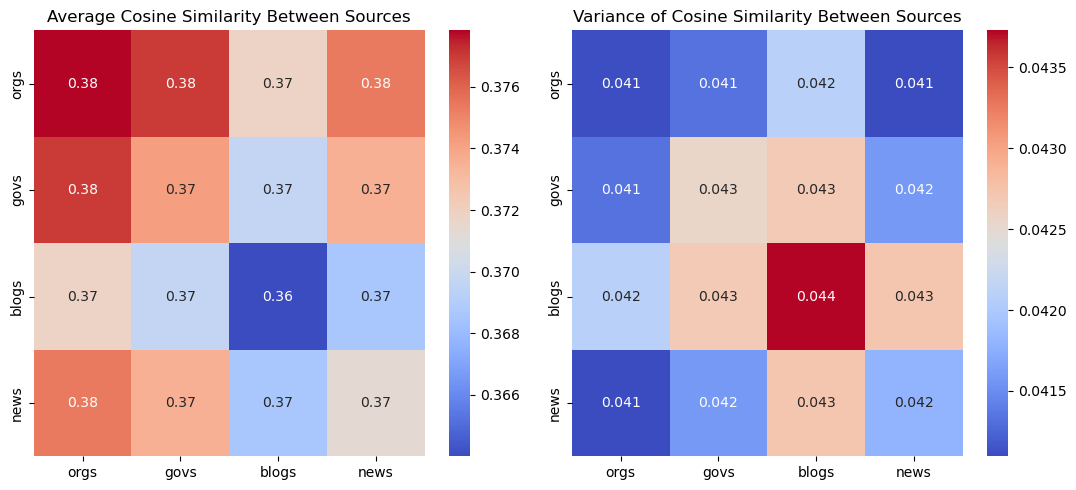

In [37]:
plt.figure(figsize=(11, 5))

# Heatmap for Average Cosine Similarity
plt.subplot(1, 2, 1)
sns.heatmap(avg_similarity, cmap='coolwarm', annot=True)
plt.title('Average Cosine Similarity Between Sources')

print('done with avg')

# Heatmap for Variance of Cosine Similarity
plt.subplot(1, 2, 2)
sns.heatmap(var_similarity, cmap='coolwarm', annot=True)
plt.title('Variance of Cosine Similarity Between Sources')
print('done with var')

plt.tight_layout()
plt.show()

No hay mucha diferencia en la complejidad del discursos entre fuentes

# 5. Sources for each president

In [18]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
file_path = r"C:\Users\asarr\Documents\Projects\pol-cul-maps-latam\president_csvs\5k"

sources_df = pd.DataFrame(columns=['President', 'Source', 'Avg_Similarity', 'Var_Similarity'])

for pres in os.listdir(file_path):
    pres_name = pres.split('.')[0]
    df = pd.read_csv(os.path.join(file_path, pres))

    df['domain'] = df['website'].apply(extract_domain)

    #create sources dfs
    orgs_df = pd.DataFrame(columns=df.columns)
    govs_df = pd.DataFrame(columns=df.columns)
    blogs_df = pd.DataFrame(columns=df.columns)
    news_df = pd.DataFrame(columns=df.columns)

    # Create lists to store rows temporarily
    orgs_list, govs_list, blogs_list, news_list = [], [], [], []

    # Iterate through rows
    for index, row in df.sample(frac=0.5).iterrows():
        if pd.isna(row['domain']):
            continue
        if 'org' in row['domain']:
            orgs_list.append(row)
        elif 'gov' in row['domain']:
            govs_list.append(row)
        else:
            if row['genre'] == 'b':
                blogs_list.append(row)
            else:
                news_list.append(row)

    # Convert lists to DataFrames
    orgs_df = pd.concat([orgs_df, pd.DataFrame(orgs_list)], ignore_index=True)
    govs_df = pd.concat([govs_df, pd.DataFrame(govs_list)], ignore_index=True)
    blogs_df = pd.concat([blogs_df, pd.DataFrame(blogs_list)], ignore_index=True)
    news_df = pd.concat([news_df, pd.DataFrame(news_list)], ignore_index=True)

    tagged_data = []

    for i, pres_df in enumerate([orgs_df, govs_df, blogs_df, news_df]):
        name = names[i]
        tagged_data += [TaggedDocument(words=doc, tags=[name + '_' + str(j)]) for j, doc in enumerate(pres_df['normalized_text'])]

        model = Doc2Vec(vector_size=100, window=6, min_count=2, epochs = 40)
        model.build_vocab(tagged_data)
        model.train(tagged_data, total_examples=model.corpus_count, epochs=model.epochs)

        #calc avg and var similarity
        avg, var = dist_and_cv_dv(model)

        #compile
        new_row = pd.DataFrame([{'President': pres_name, 'Source': name, 'Avg_Similarity': avg, 'Var_Similarity': var}])
        sources_df = pd.concat([sources_df, new_row], ignore_index=True)
    
    print(f'Done with {pres_name}')


In [41]:
presidents = sources_df['President'].unique()
ideology = [12.45, 13.27, 6.24, 16.45, 15.7, 2.65, 12.45, 8.35, 4.2, 12.71, 2, 17.33, 10, 12.71, 17.33, 5.4, 16.24, 2.65, 17.87, 11.71, 3.44, 5.23, 5.36,
            8.55, 11.55, 16.85, 16.33, 2, 17.67, 6.36, 6.64, 18.2, 16.88, 15]

populism = [1, 0, 0.21250001, 0.125, 0.2375, 1.9166666, 0, 0.125, 1.7333333, 0.25, 0.625, 0.46250001, 1, 0, 0.33333334, 0, 0.037500001,
            1.6375, 0.5, 0.375, 1.4625, 0.125, 0.5, 1.25, 0, 0.34999999, 0.15000001, 0.625, 0.0625, 0.4, 0.21250001, 0, 0.25, 0.5]

for i in range(len(presidents)):
    sources_df.loc[sources_df['President'] == presidents[i], 'Ideology'] = ideology[i]
    sources_df.loc[sources_df['President'] == presidents[i], 'Populism'] = populism[i]

#sorted dfs
sources_df_idel = sources_df.sort_values(by=['Ideology', 'President'])
sources_df_popl = sources_df.sort_values(by=['Populism', 'President'])

## 5.1 Internal complexity

Ideology:

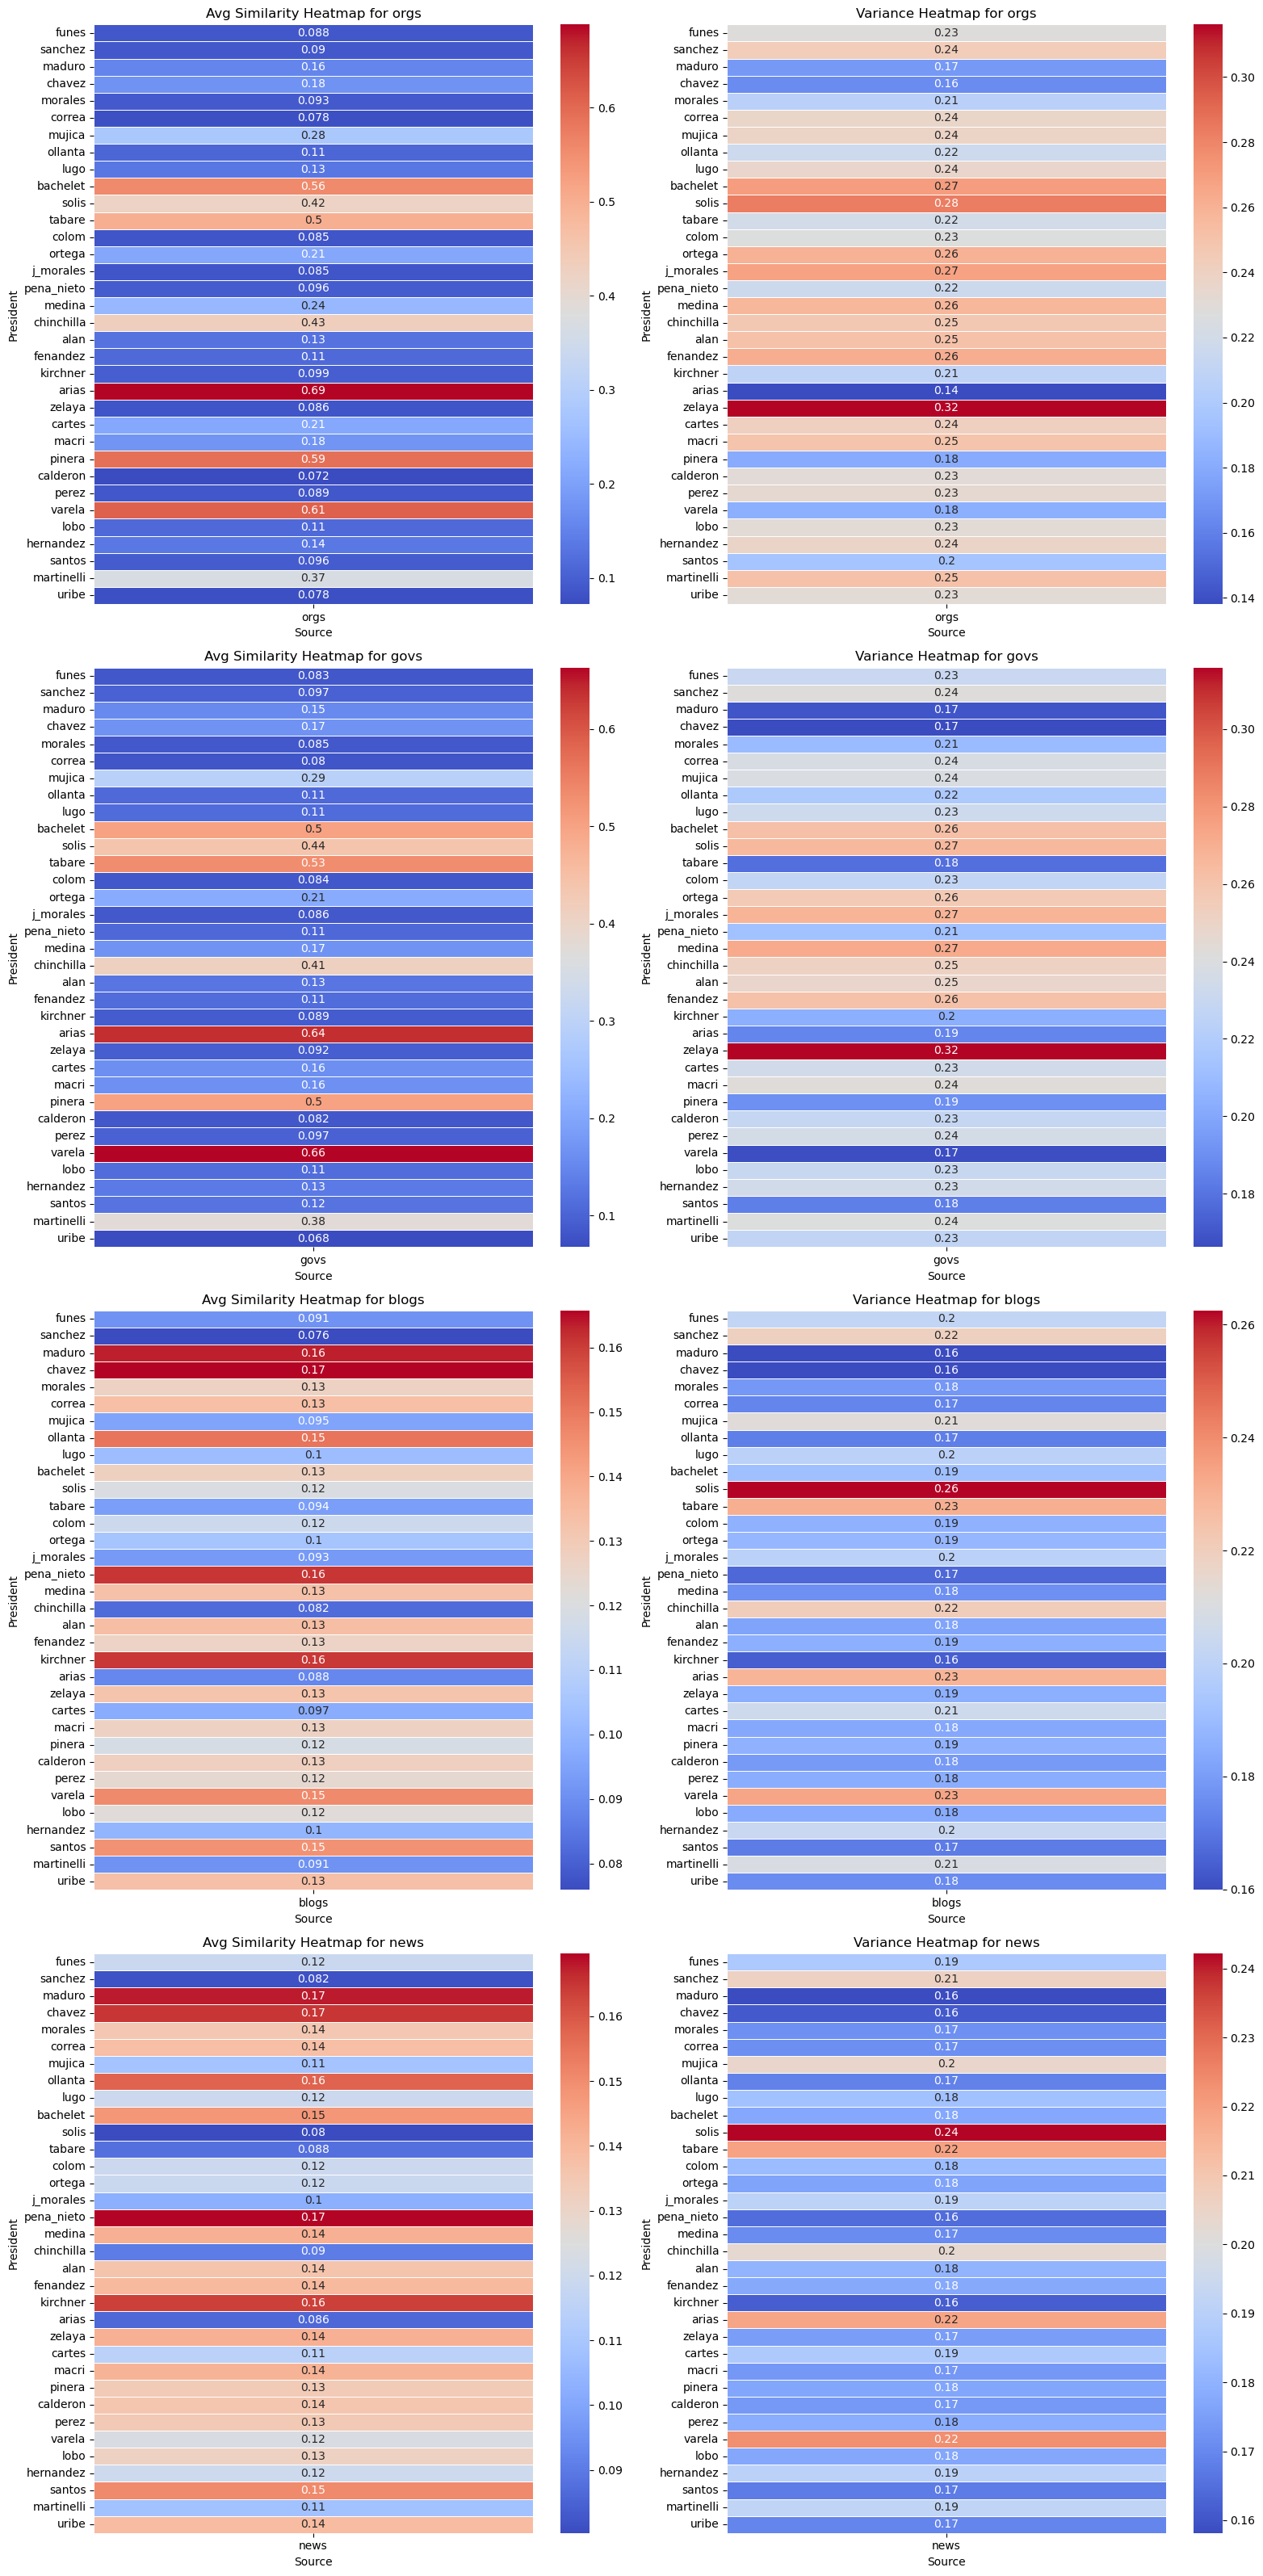

In [46]:
sources = sources_df['Source'].unique()  # Get the unique sources

# Set up a figure for all heatmaps
plt.figure(figsize=(16, len(sources) * 8))  # Adjust height based on the number of sources

# Loop through each source and create heatmaps
for i, source in enumerate(sources):
    # Filter the data for the current source
    source_data = sources_df[sources_df['Source'] == source].sort_values(by='Ideology')

    source_data['President'] = pd.Categorical(
        source_data['President'], 
        categories=source_data['President'], 
        ordered=True
    )

    # Pivot the data for Avg_Similarity
    avg_similarity_data = source_data.pivot(index='President', columns='Source', values='Avg_Similarity')

    # Pivot the data for Var_Similarity
    var_similarity_data = source_data.pivot(index='President', columns='Source', values='Var_Similarity')

    # Create the heatmap for Avg_Similarity
    plt.subplot(len(sources), 2, 2 * i + 1)
    sns.heatmap(avg_similarity_data, annot=True, cmap='coolwarm', linewidths=.5)
    plt.title(f'Avg Similarity Heatmap for {source}')

    # Create the heatmap for Var_Similarity
    plt.subplot(len(sources), 2, 2 * i + 2)
    sns.heatmap(var_similarity_data, annot=True, cmap='coolwarm', linewidths=.5)
    plt.title(f'Variance Heatmap for {source}')

plt.tight_layout()
plt.show()

Populism:

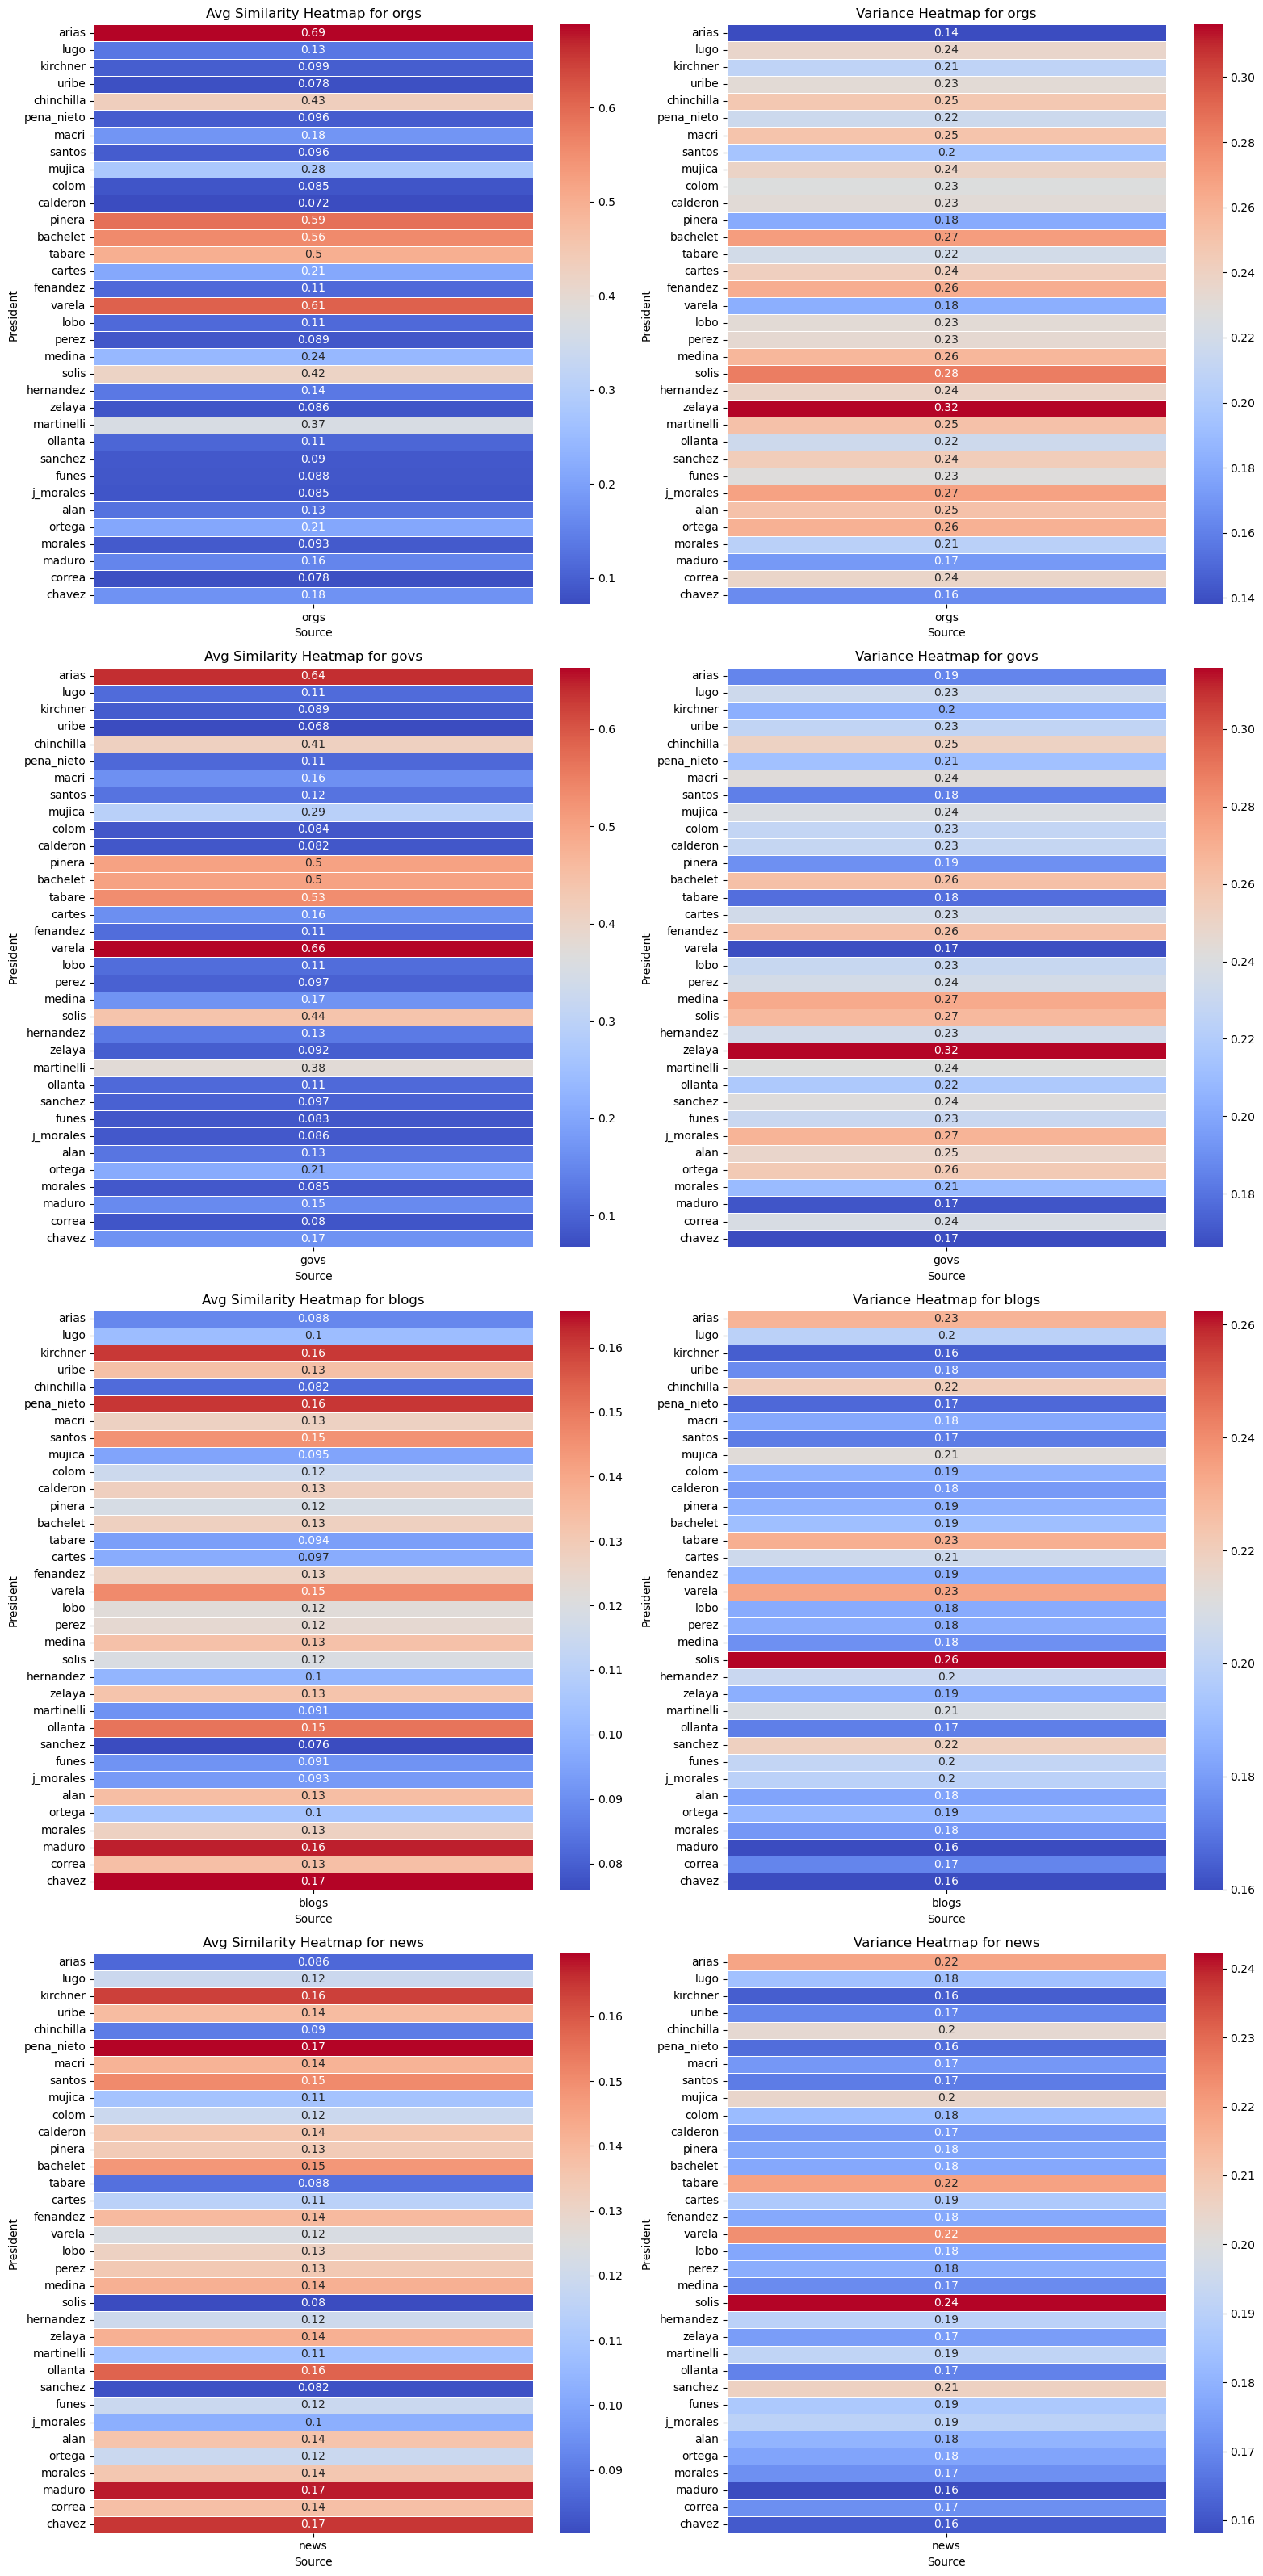

In [47]:
# Set up a figure for all heatmaps
plt.figure(figsize=(16, len(sources) * 8))  # Adjust height based on the number of sources

# Loop through each source and create heatmaps
for i, source in enumerate(sources):
    # Filter the data for the current source
    source_data = sources_df[sources_df['Source'] == source].sort_values(by='Populism')

    source_data['President'] = pd.Categorical(
        source_data['President'], 
        categories=source_data['President'], 
        ordered=True
    )

    # Pivot the data for Avg_Similarity
    avg_similarity_data = source_data.pivot(index='President', columns='Source', values='Avg_Similarity')

    # Pivot the data for Var_Similarity
    var_similarity_data = source_data.pivot(index='President', columns='Source', values='Var_Similarity')

    # Create the heatmap for Avg_Similarity
    plt.subplot(len(sources), 2, 2 * i + 1)
    sns.heatmap(avg_similarity_data, annot=True, cmap='coolwarm', linewidths=.5)
    plt.title(f'Avg Similarity Heatmap for {source}')

    # Create the heatmap for Var_Similarity
    plt.subplot(len(sources), 2, 2 * i + 2)
    sns.heatmap(var_similarity_data, annot=True, cmap='coolwarm', linewidths=.5)
    plt.title(f'Variance Heatmap for {source}')

plt.tight_layout()
plt.show()

## 5.2 Inter president similarity

### Orgs

done with calcs, now plotting
done with avg
done with var


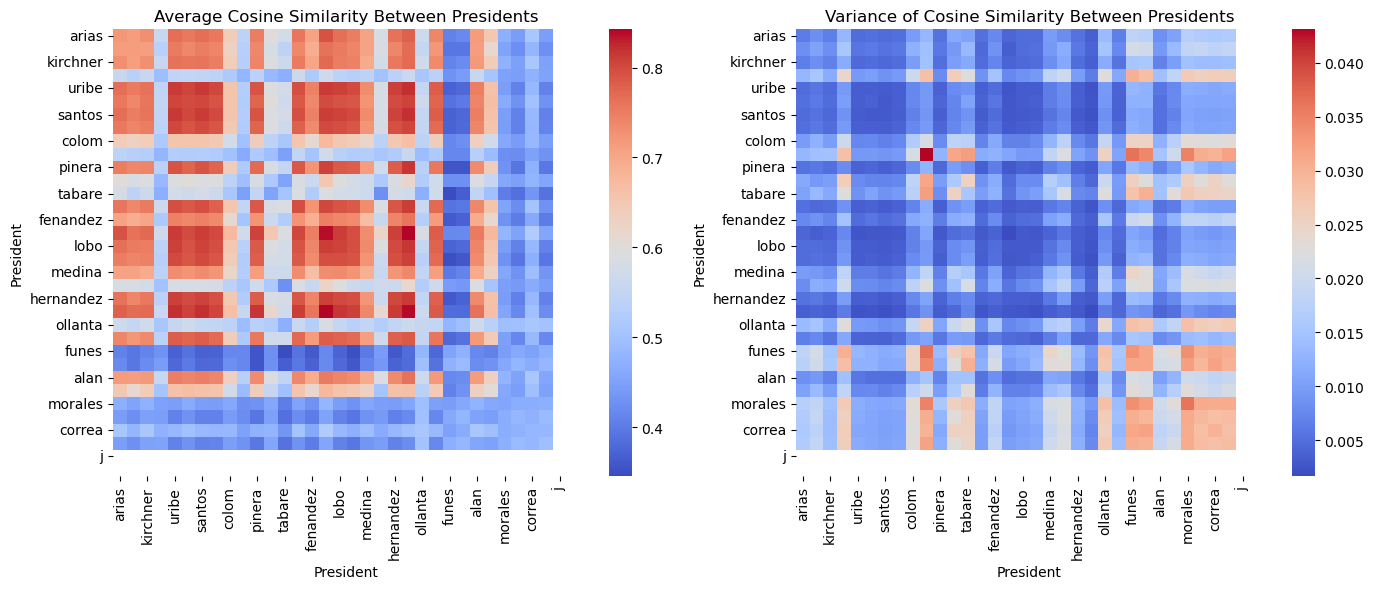

In [61]:
tagged_data = []
pres_names = []

#orgs
for df in os.listdir(file_path):
    name = df.split('.')[0]
    pres_names.append(name)
    pres_df = pd.read_csv(f'{file_path}\{df}')
    pres_df['domain'] = pres_df['website'].apply(extract_domain)
    
    #use only rows where -org- is in the domain
    pres_df = pres_df.query('domain.str.contains("org")', engine='python').sample(frac=0.33)

    tagged_data += [TaggedDocument(words=doc, tags=[name + '_' + str(j)]) for j, doc in enumerate(pres_df['normalized_text'])]

model = Doc2Vec(vector_size=100, window=6, min_count=2, epochs = 40)
model.build_vocab(tagged_data)
model.train(tagged_data, total_examples=model.corpus_count, epochs=model.epochs)

cs_dict = {'President': []}

for i, vector in enumerate(model.dv.vectors):
    pres = model.dv.index_to_key[i].split('_')[0]
    cs_dict['President'].append(pres)
    row = [cosine_similarity_adapter(vector, vector2) for vector2 in model.dv.vectors]
    cs_dict[model.dv.index_to_key[i]] = row

df = pd.DataFrame(cs_dict)

p_id = { p: ideology[i] for i, p in enumerate(presidents)}
p_pol = { p: populism[i] for i, p in enumerate(presidents)}

df['populist'] = df['President'].map(p_pol)
df['ideology'] = df['President'].map(p_id)

df_pol = df.sort_values(by=['populist', 'President'])
df_idel = df.sort_values(by=['ideology', 'President'])

for column in df_pol.columns:
    if column != 'President':
        df_pol[column] = pd.to_numeric(df[column], errors='coerce')

# Get unique presidents
presidents = df_pol['President'].unique()

# Initialize matrices for average and variance
avg_similarity = pd.DataFrame(np.zeros((len(presidents), len(presidents))), index=presidents, columns=presidents)
var_similarity = pd.DataFrame(np.zeros((len(presidents), len(presidents))), index=presidents, columns=presidents)

# Calculate average and variance of cosine similarities
for pres1 in presidents:
    for pres2 in presidents:
        # Get documents for each president
        docs_pres1 = df_pol[df_pol['President'] == pres1].drop(columns=['President']).values
        docs_pres2 = df_pol[df_pol['President'] == pres2].drop(columns=['President']).values
        
        # Collect similarities between all pairs of documents from pres1 and pres2
        similarities = []
        for doc1 in docs_pres1:
            for doc2 in docs_pres2:
                if not np.array_equal(doc1, doc2):
                    similarities.append(np.dot(doc1, doc2) / (np.linalg.norm(doc1) * np.linalg.norm(doc2)))
        
        # Calculate mean and variance if there are similarities
        if similarities:
            avg_similarity.loc[pres1, pres2] = np.mean(similarities)
            var_similarity.loc[pres1, pres2] = np.var(similarities)

print('done with calcs, now plotting')

# Step 2: Create Heatmaps
plt.figure(figsize=(14, 6))

# Heatmap for Average Cosine Similarity
plt.subplot(1, 2, 1)
sns.heatmap(avg_similarity, cmap='coolwarm')
plt.title('Average Cosine Similarity Between Presidents')
plt.xlabel('President')
plt.ylabel('President')

print('done with avg')

# Heatmap for Variance of Cosine Similarity
plt.subplot(1, 2, 2)
sns.heatmap(var_similarity, cmap='coolwarm')
plt.title('Variance of Cosine Similarity Between Presidents')
plt.xlabel('President')
plt.ylabel('President')

print('done with var')

plt.tight_layout()
plt.show()

### Gov sites

In [1]:
tagged_data = []
pres_names = []

#govs
for df in os.listdir(file_path):
    name = df.split('.')[0]
    pres_names.append(name)
    pres_df = pd.read_csv(f'{file_path}\{df}')
    pres_df['domain'] = pres_df['website'].apply(extract_domain)
    
    pres_df = pres_df.query('domain.str.contains("gov")', engine='python').sample(frac=0.33)

    tagged_data += [TaggedDocument(words=doc, tags=[name + '_' + str(j)]) for j, doc in enumerate(pres_df['normalized_text'])]

model = Doc2Vec(vector_size=100, window=6, min_count=2, epochs = 40)
model.build_vocab(tagged_data)
model.train(tagged_data, total_examples=model.corpus_count, epochs=model.epochs)

print('done training')

cs_dict = {'President': []}

for i, vector in enumerate(model.dv.vectors):
    pres = model.dv.index_to_key[i].split('_')[0]
    cs_dict['President'].append(pres)
    row = [cosine_similarity_adapter(vector, vector2) for vector2 in model.dv.vectors]
    cs_dict[model.dv.index_to_key[i]] = row

df = pd.DataFrame(cs_dict)

p_id = { p: ideology[i] for i, p in enumerate(presidents)}
p_pol = { p: populism[i] for i, p in enumerate(presidents)}

df['populist'] = df['President'].map(p_pol)
df['ideology'] = df['President'].map(p_id)

df_pol = df.sort_values(by=['populist', 'President'])
df_idel = df.sort_values(by=['ideology', 'President'])

for column in df_pol.columns:
    if column != 'President':
        df_pol[column] = pd.to_numeric(df[column], errors='coerce')

# Get unique presidents
presidents = df_pol['President'].unique()

# Initialize matrices for average and variance
avg_similarity = pd.DataFrame(np.zeros((len(presidents), len(presidents))), index=presidents, columns=presidents)
var_similarity = pd.DataFrame(np.zeros((len(presidents), len(presidents))), index=presidents, columns=presidents)

# Calculate average and variance of cosine similarities
for pres1 in presidents:
    for pres2 in presidents:
        # Get documents for each president
        docs_pres1 = df_pol[df_pol['President'] == pres1].drop(columns=['President']).values
        docs_pres2 = df_pol[df_pol['President'] == pres2].drop(columns=['President']).values
        
        # Collect similarities between all pairs of documents from pres1 and pres2
        similarities = []
        for doc1 in docs_pres1:
            for doc2 in docs_pres2:
                if not np.array_equal(doc1, doc2):
                    similarities.append(np.dot(doc1, doc2) / (np.linalg.norm(doc1) * np.linalg.norm(doc2)))
        
        # Calculate mean and variance if there are similarities
        if similarities:
            avg_similarity.loc[pres1, pres2] = np.mean(similarities)
            var_similarity.loc[pres1, pres2] = np.var(similarities)

print('done with calcs, now plotting')

# Step 2: Create Heatmaps
plt.figure(figsize=(14, 6))

# Heatmap for Average Cosine Similarity
plt.subplot(1, 2, 1)
sns.heatmap(avg_similarity, cmap='coolwarm')
plt.title('Average Cosine Similarity Between Presidents')
plt.xlabel('President')
plt.ylabel('President')

print('done with avg')

# Heatmap for Variance of Cosine Similarity
plt.subplot(1, 2, 2)
sns.heatmap(var_similarity, cmap='coolwarm')
plt.title('Variance of Cosine Similarity Between Presidents')
plt.xlabel('President')
plt.ylabel('President')

print('done with var')

plt.tight_layout()
plt.show()

NameError: name 'os' is not defined

### Blogs

In [63]:
tagged_data = []
pres_names = []

#govs
for df in os.listdir(file_path):
    name = df.split('.')[0]
    pres_names.append(name)
    pres_df = pd.read_csv(f'{file_path}\{df}')
    pres_df['domain'] = pres_df['website'].apply(extract_domain)
    
    pres_df = pres_df.query('~domain.str.contains("gov|org") and genre == "b"', engine='python').sample(frac=0.1)

    tagged_data += [TaggedDocument(words=doc, tags=[name + '_' + str(j)]) for j, doc in enumerate(pres_df['normalized_text'])]

model = Doc2Vec(vector_size=100, window=6, min_count=2, epochs = 40)
model.build_vocab(tagged_data)
model.train(tagged_data, total_examples=model.corpus_count, epochs=model.epochs)

cs_dict = {'President': []}

for i, vector in enumerate(model.dv.vectors):
    pres = model.dv.index_to_key[i].split('_')[0]
    cs_dict['President'].append(pres)
    row = [cosine_similarity_adapter(vector, vector2) for vector2 in model.dv.vectors]
    cs_dict[model.dv.index_to_key[i]] = row

df = pd.DataFrame(cs_dict)

p_id = { p: ideology[i] for i, p in enumerate(presidents)}
p_pol = { p: populism[i] for i, p in enumerate(presidents)}

df['populist'] = df['President'].map(p_pol)
df['ideology'] = df['President'].map(p_id)

df_pol = df.sort_values(by=['populist', 'President'])
df_idel = df.sort_values(by=['ideology', 'President'])

for column in df_pol.columns:
    if column != 'President':
        df_pol[column] = pd.to_numeric(df[column], errors='coerce')

# Get unique presidents
presidents = df_pol['President'].unique()

# Initialize matrices for average and variance
avg_similarity = pd.DataFrame(np.zeros((len(presidents), len(presidents))), index=presidents, columns=presidents)
var_similarity = pd.DataFrame(np.zeros((len(presidents), len(presidents))), index=presidents, columns=presidents)

# Calculate average and variance of cosine similarities
for pres1 in presidents:
    for pres2 in presidents:
        # Get documents for each president
        docs_pres1 = df_pol[df_pol['President'] == pres1].drop(columns=['President']).values
        docs_pres2 = df_pol[df_pol['President'] == pres2].drop(columns=['President']).values
        
        # Collect similarities between all pairs of documents from pres1 and pres2
        similarities = []
        for doc1 in docs_pres1:
            for doc2 in docs_pres2:
                if not np.array_equal(doc1, doc2):
                    similarities.append(np.dot(doc1, doc2) / (np.linalg.norm(doc1) * np.linalg.norm(doc2)))
        
        # Calculate mean and variance if there are similarities
        if similarities:
            avg_similarity.loc[pres1, pres2] = np.mean(similarities)
            var_similarity.loc[pres1, pres2] = np.var(similarities)

print('done with calcs, now plotting')

# Step 2: Create Heatmaps
plt.figure(figsize=(14, 6))

# Heatmap for Average Cosine Similarity
plt.subplot(1, 2, 1)
sns.heatmap(avg_similarity, cmap='coolwarm')
plt.title('Average Cosine Similarity Between Presidents')
plt.xlabel('President')
plt.ylabel('President')

print('done with avg')

# Heatmap for Variance of Cosine Similarity
plt.subplot(1, 2, 2)
sns.heatmap(var_similarity, cmap='coolwarm')
plt.title('Variance of Cosine Similarity Between Presidents')
plt.xlabel('President')
plt.ylabel('President')

print('done with var')

plt.tight_layout()
plt.show()

### News

In [ ]:
tagged_data = []
pres_names = []

#govs
for df in os.listdir(file_path):
    name = df.split('.')[0]
    pres_names.append(name)
    pres_df = pd.read_csv(f'{file_path}\{df}')
    pres_df['domain'] = pres_df['website'].apply(extract_domain)
    
    pres_df = pres_df.query('~domain.str.contains("gov|org") and genre != "b"', engine='python').sample(frac=0.33)

    tagged_data += [TaggedDocument(words=doc, tags=[name + '_' + str(j)]) for j, doc in enumerate(pres_df['normalized_text'])]

model = Doc2Vec(vector_size=100, window=6, min_count=2, epochs = 40)
model.build_vocab(tagged_data)
model.train(tagged_data, total_examples=model.corpus_count, epochs=model.epochs)

cs_dict = {'President': []}

for i, vector in enumerate(model.dv.vectors):
    pres = model.dv.index_to_key[i].split('_')[0]
    cs_dict['President'].append(pres)
    row = [cosine_similarity_adapter(vector, vector2) for vector2 in model.dv.vectors]
    cs_dict[model.dv.index_to_key[i]] = row

df = pd.DataFrame(cs_dict)

p_id = { p: ideology[i] for i, p in enumerate(presidents)}
p_pol = { p: populism[i] for i, p in enumerate(presidents)}

df['populist'] = df['President'].map(p_pol)
df['ideology'] = df['President'].map(p_id)

df_pol = df.sort_values(by=['populist', 'President'])
df_idel = df.sort_values(by=['ideology', 'President'])

for column in df_pol.columns:
    if column != 'President':
        df_pol[column] = pd.to_numeric(df[column], errors='coerce')

# Get unique presidents
presidents = df_pol['President'].unique()

# Initialize matrices for average and variance
avg_similarity = pd.DataFrame(np.zeros((len(presidents), len(presidents))), index=presidents, columns=presidents)
var_similarity = pd.DataFrame(np.zeros((len(presidents), len(presidents))), index=presidents, columns=presidents)

# Calculate average and variance of cosine similarities
for pres1 in presidents:
    for pres2 in presidents:
        # Get documents for each president
        docs_pres1 = df_pol[df_pol['President'] == pres1].drop(columns=['President']).values
        docs_pres2 = df_pol[df_pol['President'] == pres2].drop(columns=['President']).values
        
        # Collect similarities between all pairs of documents from pres1 and pres2
        similarities = []
        for doc1 in docs_pres1:
            for doc2 in docs_pres2:
                if not np.array_equal(doc1, doc2):
                    similarities.append(np.dot(doc1, doc2) / (np.linalg.norm(doc1) * np.linalg.norm(doc2)))
        
        # Calculate mean and variance if there are similarities
        if similarities:
            avg_similarity.loc[pres1, pres2] = np.mean(similarities)
            var_similarity.loc[pres1, pres2] = np.var(similarities)

print('done with calcs, now plotting')

# Step 2: Create Heatmaps
plt.figure(figsize=(14, 6))

# Heatmap for Average Cosine Similarity
plt.subplot(1, 2, 1)
sns.heatmap(avg_similarity, cmap='coolwarm')
plt.title('Average Cosine Similarity Between Presidents')
plt.xlabel('President')
plt.ylabel('President')

print('done with avg')

# Heatmap for Variance of Cosine Similarity
plt.subplot(1, 2, 2)
sns.heatmap(var_similarity, cmap='coolwarm')
plt.title('Variance of Cosine Similarity Between Presidents')
plt.xlabel('President')
plt.ylabel('President')

print('done with var')

plt.tight_layout()
plt.show()